Project Title: Customer Churn Analysis and Prediction ***  
Business Analyst: Oveis Bagheri ***  
Project Period: March 01, 2026 – April 01, 2026 ***  
Powered by: Codveda Technologies ***  


1 — Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np

# load datasets
train = pd.read_csv("churn-bigml-80.csv")
test = pd.read_csv("churn-bigml-20.csv")

# preview
train.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


2 — Dataset Shape & Structure

In [2]:
train.shape
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

3 — Missing Values Check

In [3]:
train.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

4 — Duplicate Check

In [4]:
train.duplicated().sum()

np.int64(0)

5 — Target Variable Distribution

In [5]:
train['Churn'].value_counts()
train['Churn'].value_counts(normalize=True)

Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64

6 — Descriptive Statistics (Overview)

In [6]:
train.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


Data Cleaning & Preparation

7 — Drop Unnecessary Columns

In [7]:
train = train.drop(columns=['State'])
test = test.drop(columns=['State'])

8 — Convert Categorical Variables

In [8]:
binary_cols = ['International plan', 'Voice mail plan', 'Churn']

for col in binary_cols:
    train[col] = train[col].map({'Yes':1, 'No':0, True:1, False:0})
    test[col] = test[col].map({'Yes':1, 'No':0, True:1, False:0})

9 — Check Data After Encoding

In [9]:
train.head()
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Account length          2666 non-null   int64  
 1   Area code               2666 non-null   int64  
 2   International plan      2666 non-null   int64  
 3   Voice mail plan         2666 non-null   int64  
 4   Number vmail messages   2666 non-null   int64  
 5   Total day minutes       2666 non-null   float64
 6   Total day calls         2666 non-null   int64  
 7   Total day charge        2666 non-null   float64
 8   Total eve minutes       2666 non-null   float64
 9   Total eve calls         2666 non-null   int64  
 10  Total eve charge        2666 non-null   float64
 11  Total night minutes     2666 non-null   float64
 12  Total night calls       2666 non-null   int64  
 13  Total night charge      2666 non-null   float64
 14  Total intl minutes      2666 non-null   

10 — Outlier Check

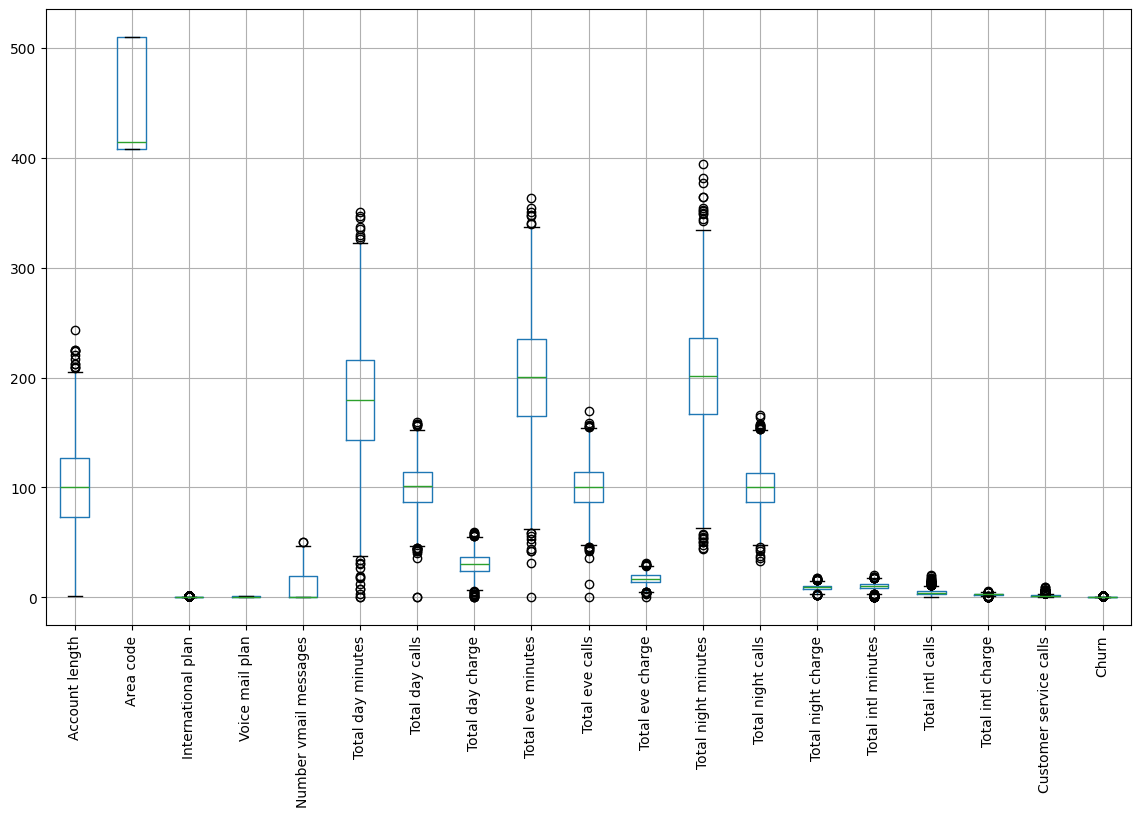

In [10]:
import matplotlib.pyplot as plt

train.boxplot(figsize=(14,8))
plt.xticks(rotation=90)
plt.show()

11 — Exploratory Data Analysis (EDA)

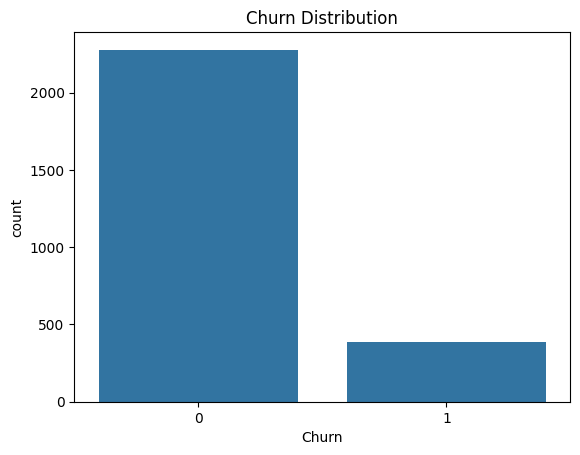

Churn
0    0.854464
1    0.145536
Name: proportion, dtype: float64

In [11]:

import matplotlib.pyplot as plt
import seaborn as sns

# Churn Distribution
sns.countplot(x='Churn', data=train)
plt.title("Churn Distribution")
plt.show()

train['Churn'].value_counts(normalize=True)

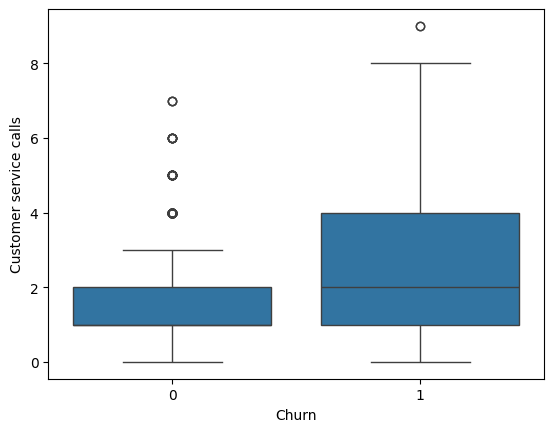

In [12]:
# Churn vs Customer Service Calls
sns.boxplot(x='Churn', y='Customer service calls', data=train)
plt.show()

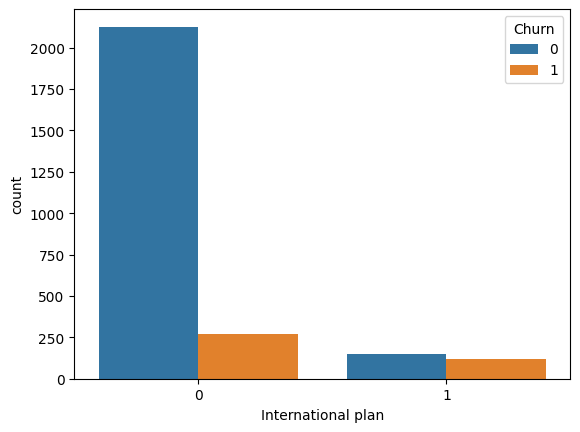

In [13]:
# Churn vs International Plan
sns.countplot(x='International plan', hue='Churn', data=train)
plt.show()

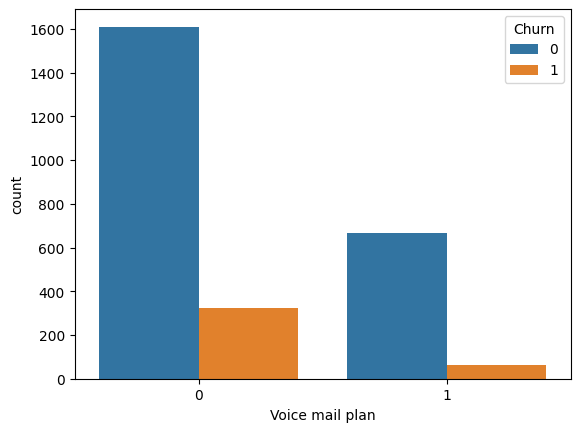

In [14]:
# Churn vs Voice Mail Plan
sns.countplot(x='Voice mail plan', hue='Churn', data=train)
plt.show()

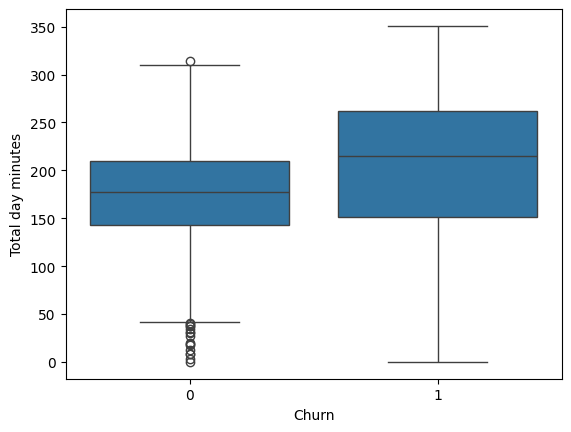

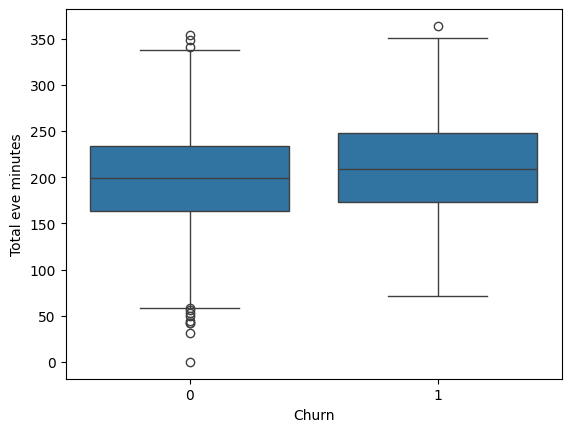

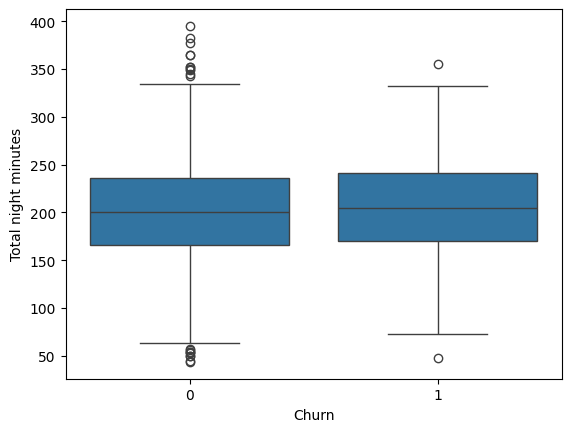

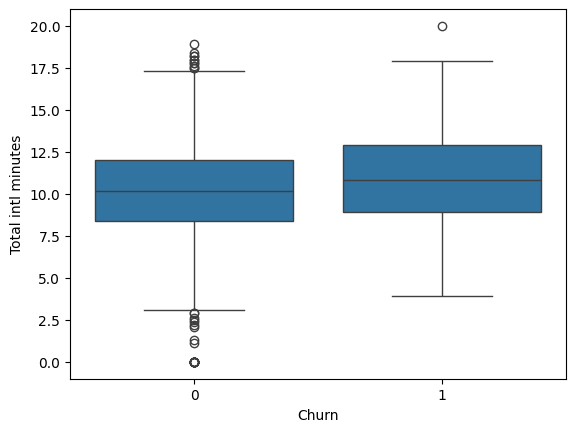

In [15]:
# Usage Behavior Analysis
sns.boxplot(x='Churn', y='Total day minutes', data=train)
plt.show()

sns.boxplot(x='Churn', y='Total eve minutes', data=train)
plt.show()

sns.boxplot(x='Churn', y='Total night minutes', data=train)
plt.show()

sns.boxplot(x='Churn', y='Total intl minutes', data=train)
plt.show()

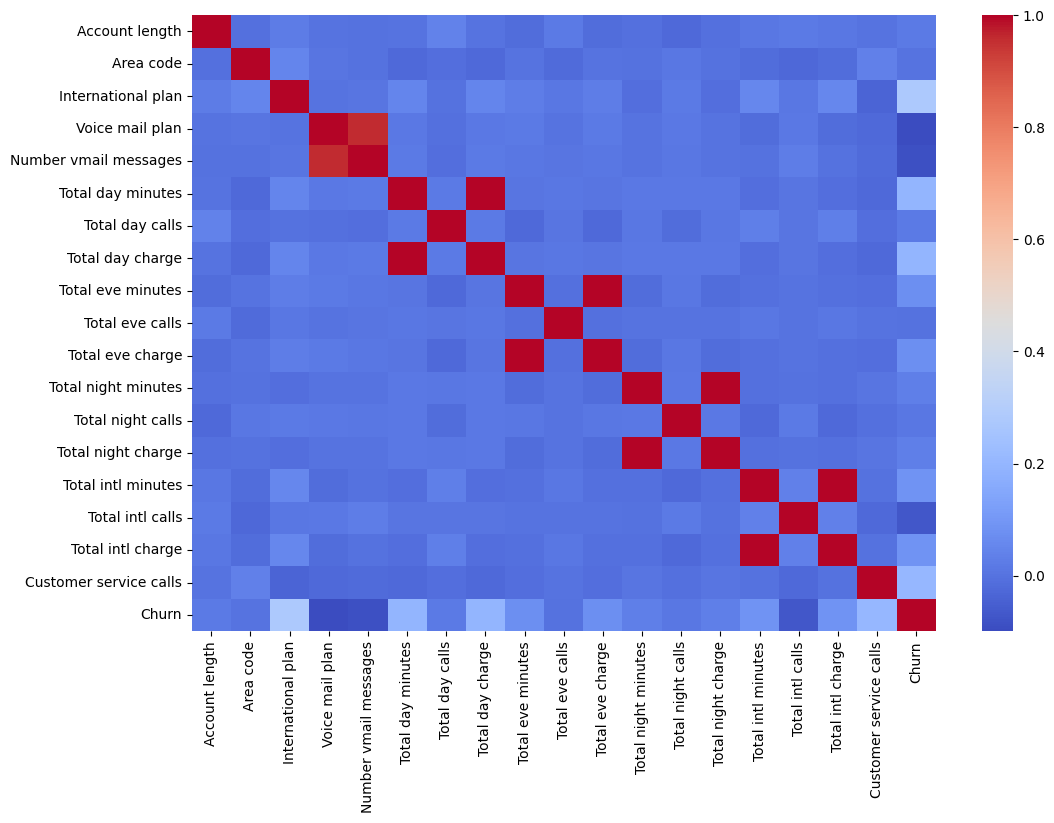

In [16]:
# Correlation Analysis
plt.figure(figsize=(12,8))
sns.heatmap(train.corr(), cmap='coolwarm')
plt.show()

12 — Predictive Modeling (Machine Learning)

In [17]:
# Define X and y
X_train = train.drop('Churn', axis=1)
y_train = train['Churn']

X_test = test.drop('Churn', axis=1)
y_test = test['Churn']

In [18]:
# Baseline Model (Logistic Regression)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Accuracy: 0.856071964017991
[[556  16]
 [ 80  15]]
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       572
           1       0.48      0.16      0.24        95

    accuracy                           0.86       667
   macro avg       0.68      0.56      0.58       667
weighted avg       0.82      0.86      0.82       667



C:\Users\ovman\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
# Main Model (Random Forest)
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9550224887556222
[[567   5]
 [ 25  70]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       572
           1       0.93      0.74      0.82        95

    accuracy                           0.96       667
   macro avg       0.95      0.86      0.90       667
weighted avg       0.95      0.96      0.95       667



In [20]:
# Feature importance analysis
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns)
feature_importance.sort_values(ascending=False)

Total day minutes         0.130693
Total day charge          0.129291
Customer service calls    0.120299
International plan        0.090640
Total eve minutes         0.068751
Total eve charge          0.063119
Total intl calls          0.054774
Total intl charge         0.044987
Total intl minutes        0.043724
Total night charge        0.040012
Total night minutes       0.038586
Total day calls           0.031952
Account length            0.031418
Total night calls         0.030137
Total eve calls           0.028987
Number vmail messages     0.026325
Voice mail plan           0.018260
Area code                 0.008044
dtype: float64